## Hypothesis 1 — Region vs Stockout

In [1]:
import libraries as lb

In [2]:
# H0: Stockout rate is equal across all regions
# H1: Stockout rate differs significantly by region

In [3]:
consumption_data = lb.pd.read_csv("Dataset/consumption_facility_cleaned.csv")
consumption_data['Stockout_Flag'] = (
    consumption_data['Out_of_Stock_Days'] > 0
).astype(int)

# Chi-Square Test 
contingency_table = lb.pd.crosstab(
    consumption_data['Region'],
    consumption_data['Stockout_Flag']
)
print("Contingency Table:")
print(contingency_table)

chi2, p_value, dof, expected = lb.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"\nSignificance Level   : 0.05")

if p_value < 0.05:
    print("Result: REJECT H0")
    print("Stockout rate differs significantly by region")
else:
    print("Result: FAIL TO REJECT H0")
    print("Stockout rate is equal across regions")

Contingency Table:
Stockout_Flag     0   1
Region                 
Ahmedabad       675  24
Bangalore       649  15
Bhubaneswar     222   5
Chennai         835  19
Coimbatore      405  18
Delhi           662  21
Guwahati        412  14
Hyderabad       913  20
Indore          637  25
Jaipur          534  20
Kanpur          175   3
Kolkata         671  14
Lucknow         709  19
Mumbai         1355  39
Nagpur          600  23
Patna           221   9
Pune            678  21
Raipur          170   4
Surat           272   3

Chi-Square Statistic : 20.1128
P-Value              : 0.3265
Degrees of Freedom   : 18

Significance Level   : 0.05
Result: FAIL TO REJECT H0
Stockout rate is equal across regions


# Region vs Stockout (Sampling Distribution of Proportion)

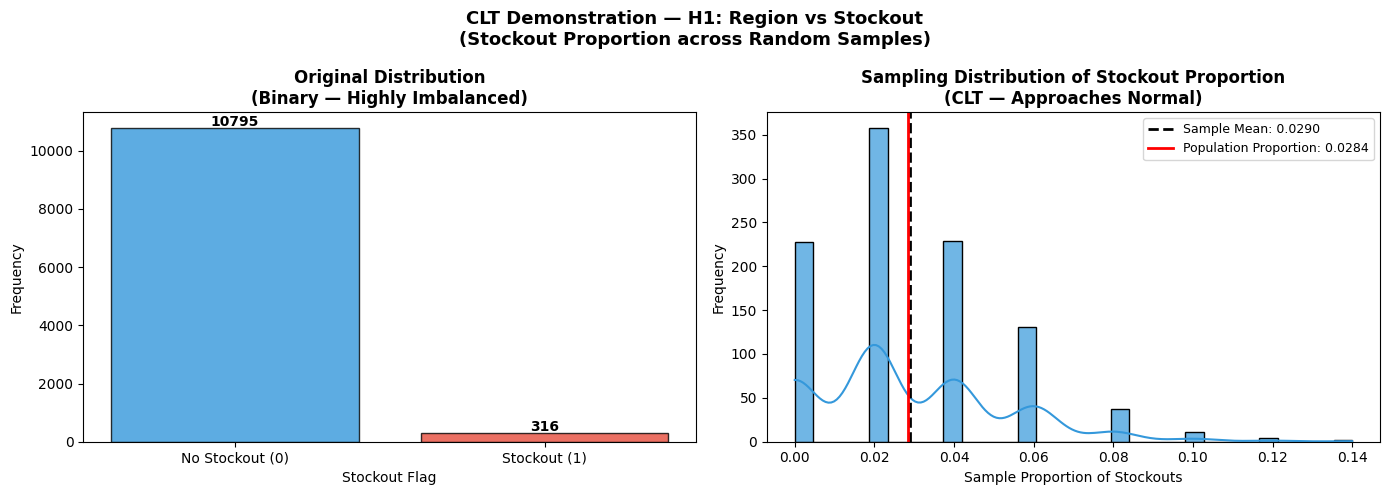

Population Stockout Proportion : 0.0284
Mean of Sample Proportions     : 0.0290
Std of Sample Proportions      : 0.0242
Standard Error (theory)        : 0.0235


In [4]:
# CLT — H1: Sampling Distribution of Stockout Proportion

col          = 'Stockout_Flag'
sample_size  = 50
n_samples    = 1000
sample_props = []

for _ in range(n_samples):
    sample = consumption_data[col].sample(sample_size, replace=True)
    sample_props.append(sample.mean())

pop_proportion = consumption_data[col].mean()

fig, axes = lb.plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
axes[0].bar(['No Stockout (0)', 'Stockout (1)'],
            consumption_data[col].value_counts().sort_index().values,
            color=['#3498db', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0].set_title('Original Distribution\n(Binary — Highly Imbalanced)', fontweight='bold')
axes[0].set_ylabel('Frequency')
axes[0].set_xlabel('Stockout Flag')
for bar, val in zip(axes[0].patches,
                    consumption_data[col].value_counts().sort_index().values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 str(val), ha='center', fontweight='bold')

# Sampling distribution
lb.sns.histplot(sample_props, kde=True, ax=axes[1],
                color='#3498db', bins=30, alpha=0.7)
axes[1].axvline(lb.np.mean(sample_props), color='black', linestyle='--', linewidth=2,
                label=f'Sample Mean: {lb.np.mean(sample_props):.4f}')
axes[1].axvline(pop_proportion, color='red', linestyle='-', linewidth=2,
                label=f'Population Proportion: {pop_proportion:.4f}')
axes[1].set_title('Sampling Distribution of Stockout Proportion\n(CLT — Approaches Normal)', fontweight='bold')
axes[1].set_xlabel('Sample Proportion of Stockouts')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)

lb.plt.suptitle('CLT Demonstration — H1: Region vs Stockout\n(Stockout Proportion across Random Samples)',
                fontsize=13, fontweight='bold')
lb.plt.tight_layout()
lb.plt.show()

print(f'Population Stockout Proportion : {pop_proportion:.4f}')
print(f'Mean of Sample Proportions     : {lb.np.mean(sample_props):.4f}')
print(f'Std of Sample Proportions      : {lb.np.std(sample_props):.4f}')
print(f'Standard Error (theory)        : {lb.np.sqrt(pop_proportion*(1-pop_proportion)/sample_size):.4f}')

# interpretation

H0: Stockout rate is equal across all regions
H1: Stockout rate differs significantly by region

Chi-Square : 20.11
P-Value    : 0.3265
DOF        : 18
Alpha      : 0.05

Result: FAIL TO REJECT H0 

Since P-Value (0.3265) > 0.05, there is no significant difference in stockout rates across regions stockout occurrence is independent of region.

## Hypothesis 2 — Wastage vs Stockout

In [5]:
# H0: Wastage has no relationship with Stockout
# H1: Wastage and Stockout are significantly related


In [6]:
consumption_data['Wastage_Flag'] = (
    consumption_data['Wastage_Units'] > 0
).astype(int)

# Chi-Square Test 
contingency_table2 = lb.pd.crosstab(
    consumption_data['Wastage_Flag'],
    consumption_data['Stockout_Flag']
)
print("Contingency Table:")
print(contingency_table2)

chi2, p_value, dof, expected = lb.chi2_contingency(contingency_table2)

print(f"\nChi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"\nSignificance Level   : 0.05")

if p_value < 0.05:
    print("Result: REJECT H0")
    print("Wastage and Stockout ARE significantly related")
else:
    print("Result: FAIL TO REJECT H0")
    print("Wastage has NO significant relationship with Stockout")

Contingency Table:
Stockout_Flag     0    1
Wastage_Flag            
0              9522    0
1              1273  316

Chi-Square Statistic : 1941.8545
P-Value              : 0.0000
Degrees of Freedom   : 1

Significance Level   : 0.05
Result: REJECT H0
Wastage and Stockout ARE significantly related


# Wastage vs Stockout (Sampling Distribution of Proportion)

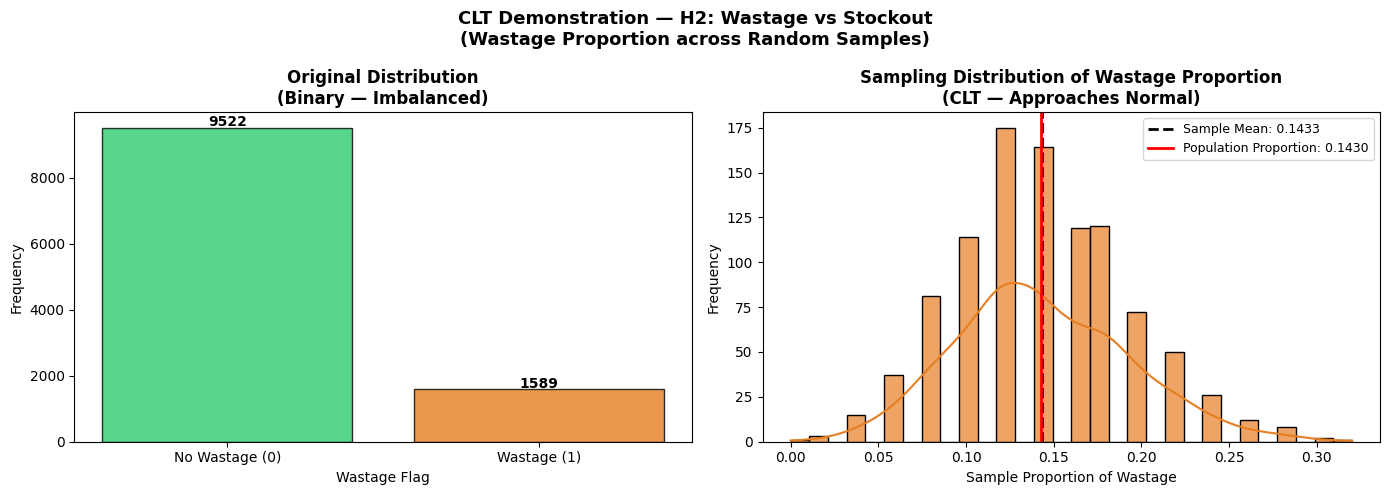

Population Wastage Proportion  : 0.1430
Mean of Sample Proportions     : 0.1433
Std of Sample Proportions      : 0.0497
Standard Error (theory)        : 0.0495


In [7]:
# CLT — H2: Sampling Distribution of Wastage Proportion

col          = 'Wastage_Flag'
sample_size  = 50
n_samples    = 1000
sample_props = []

for _ in range(n_samples):
    sample = consumption_data[col].sample(sample_size, replace=True)
    sample_props.append(sample.mean())

pop_proportion = consumption_data[col].mean()

fig, axes = lb.plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
axes[0].bar(['No Wastage (0)', 'Wastage (1)'],
            consumption_data[col].value_counts().sort_index().values,
            color=['#2ecc71', '#e67e22'], alpha=0.8, edgecolor='black')
axes[0].set_title('Original Distribution\n(Binary — Imbalanced)', fontweight='bold')
axes[0].set_ylabel('Frequency')
axes[0].set_xlabel('Wastage Flag')
for bar, val in zip(axes[0].patches,
                    consumption_data[col].value_counts().sort_index().values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 str(val), ha='center', fontweight='bold')

# Sampling distribution
lb.sns.histplot(sample_props, kde=True, ax=axes[1],
                color='#e67e22', bins=30, alpha=0.7)
axes[1].axvline(lb.np.mean(sample_props), color='black', linestyle='--', linewidth=2,
                label=f'Sample Mean: {lb.np.mean(sample_props):.4f}')
axes[1].axvline(pop_proportion, color='red', linestyle='-', linewidth=2,
                label=f'Population Proportion: {pop_proportion:.4f}')
axes[1].set_title('Sampling Distribution of Wastage Proportion\n(CLT — Approaches Normal)', fontweight='bold')
axes[1].set_xlabel('Sample Proportion of Wastage')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)

lb.plt.suptitle('CLT Demonstration — H2: Wastage vs Stockout\n(Wastage Proportion across Random Samples)',
                fontsize=13, fontweight='bold')
lb.plt.tight_layout()
lb.plt.show()

print(f'Population Wastage Proportion  : {pop_proportion:.4f}')
print(f'Mean of Sample Proportions     : {lb.np.mean(sample_props):.4f}')
print(f'Std of Sample Proportions      : {lb.np.std(sample_props):.4f}')
print(f'Standard Error (theory)        : {lb.np.sqrt(pop_proportion*(1-pop_proportion)/sample_size):.4f}')

# Interpretation:

H0: Wastage has no relationship with Stockout
H1: Wastage and Stockout are significantly related

Chi-Square : 1941.85
P-Value    : 0.0000
DOF        : 1
Alpha      : 0.05

Result: REJECT H0 

Since P-Value (0.0000) < 0.05, Wastage and Stockout are strongly related — medicines that are wasted are also associated with stockout events.

# Consumption vs Stockout

In [8]:
# H0: Daily consumption is equal for stockout vs non-stockout records
# H1: Daily consumption differs significantly


In [9]:
stockout_yes = consumption_data[
    consumption_data['Stockout_Flag'] == 1]['Daily_Consumption_Units']

stockout_no = consumption_data[
    consumption_data['Stockout_Flag'] == 0]['Daily_Consumption_Units']

print("Stockout = 1 (Daily Consumption):")
print(stockout_yes.describe().round(3))

print("\nStockout = 0 (Daily Consumption):")
print(stockout_no.describe().round(3))

# T-Test 
t_stat, p_value = lb.stats.ttest_ind(stockout_yes, stockout_no)

print(f"\nT-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")
print(f"\nSignificance Level : 0.05")

if p_value < 0.05:
    print("Result: REJECT H0")
    print("Daily consumption differs significantly")
    print("between stockout and non-stockout records")
else:
    print("Result: FAIL TO REJECT H0")
    print("Daily consumption is equal across")
    print("stockout and non-stockout records")

Stockout = 1 (Daily Consumption):
count    316.000
mean       0.815
std        1.470
min        0.100
25%        0.200
50%        0.400
75%        1.000
max       13.700
Name: Daily_Consumption_Units, dtype: float64

Stockout = 0 (Daily Consumption):
count    10795.000
mean         0.664
std          2.468
min          0.000
25%          0.100
50%          0.200
75%          0.500
max        143.000
Name: Daily_Consumption_Units, dtype: float64

T-Statistic : 1.0816
P-Value     : 0.2795

Significance Level : 0.05
Result: FAIL TO REJECT H0
Daily consumption is equal across
stockout and non-stockout records


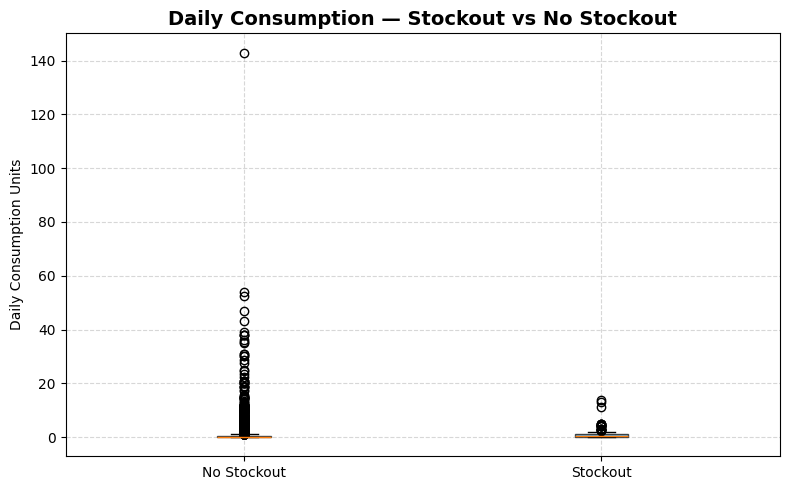

In [10]:
# Visualize 
lb.plt.figure(figsize=(8, 5))
lb.plt.boxplot([stockout_no, stockout_yes],
               labels=['No Stockout', 'Stockout'],
               patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.7))
lb.plt.title('Daily Consumption — Stockout vs No Stockout',
             fontsize=14, fontweight='bold')
lb.plt.ylabel('Daily Consumption Units')
lb.plt.grid(True, linestyle='--', alpha=0.5)
lb.plt.tight_layout()
lb.plt.show()

# Interpretations:

H0: Daily consumption is equal for stockout vs non-stockout records
H1: Daily consumption differs significantly

T-Statistic : 1.0816
P-Value     : 0.2795
Alpha       : 0.05

Result: FAIL TO REJECT H0

Since P-Value (0.2795) > 0.05, daily consumption does not differ significantly between stockout and non-stockout records.

Based on hypothesis testing:

Target: Stockout_Flag
Key Feature: Wastage_Flag ← strongest predictor
Model: Logistic Regression or KNN Classifier

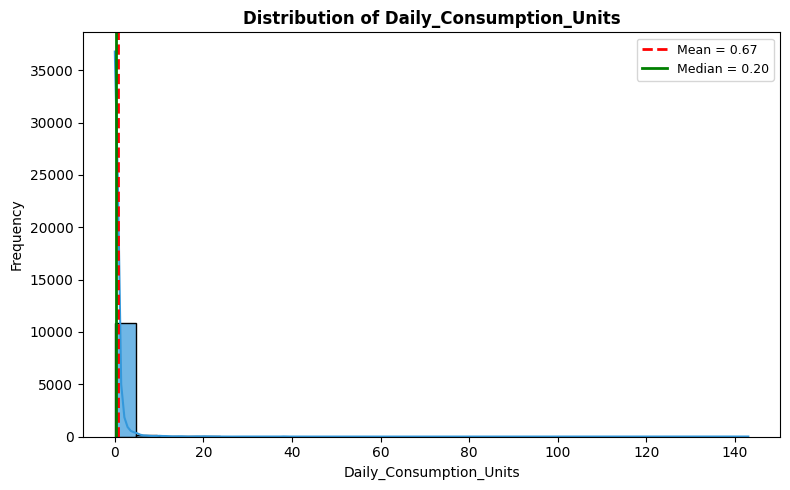

In [11]:
# Distribution Curve

# Distribution Curve

num_cols = ['Daily_Consumption_Units']

# Plot (dynamic size based on columns)
fig, axes = lb.plt.subplots(1, len(num_cols), figsize=(8, 5))

# If only one column, convert to list
if len(num_cols) == 1:
    axes = [axes]

colors = ['#3498db']

for i, col in enumerate(num_cols):
    lb.sns.histplot(
        consumption_data[col],
        kde=True,
        ax=axes[i],
        color=colors[i],
        bins=30,
        alpha=0.7
    )

    mean_val = consumption_data[col].mean()
    median_val = consumption_data[col].median()

    # Mean Line
    axes[i].axvline(mean_val, color='red', linestyle='--',
                    linewidth=2, label=f'Mean = {mean_val:.2f}')

    # Median Line
    axes[i].axvline(median_val, color='green', linestyle='-',
                    linewidth=2, label=f'Median = {median_val:.2f}')

    axes[i].set_title(f'Distribution of {col}',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

lb.plt.tight_layout()
lb.plt.show()

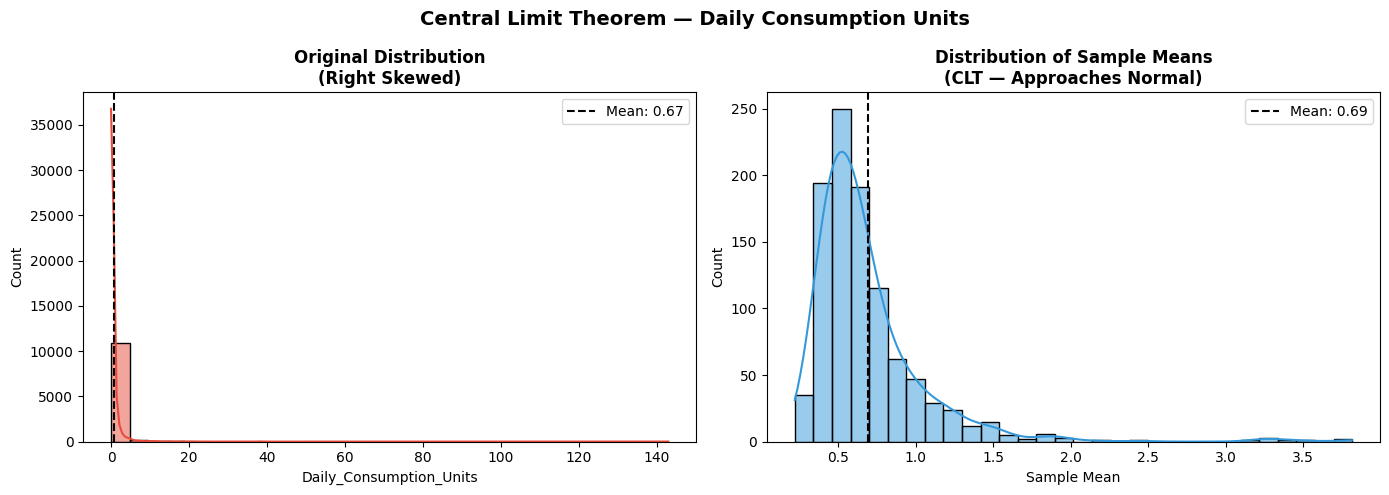

Original Std  : 2.4455
Sample Mean Std: 0.3870
Standard Error : 0.3458


In [12]:
# CLT Demonstration 
import random

col = 'Daily_Consumption_Units'
sample_means = []
sample_size = 50    # n ≥ 30 satisfies CLT
n_samples = 1000    # number of samples

for _ in range(n_samples):
    sample = consumption_data[col].sample(sample_size)
    sample_means.append(sample.mean())

# Plot Original vs Sample Means 
fig, axes = lb.plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
lb.sns.histplot(consumption_data[col],
                kde=True, ax=axes[0],
                color='#e74c3c', bins=30)
axes[0].set_title('Original Distribution\n(Right Skewed)',
                   fontweight='bold')
axes[0].set_xlabel(col)
axes[0].axvline(consumption_data[col].mean(),
                color='black', linestyle='--',
                label=f"Mean: {consumption_data[col].mean():.2f}")
axes[0].legend()

# Sample means distribution
lb.sns.histplot(sample_means,
                kde=True, ax=axes[1],
                color='#3498db', bins=30)
axes[1].set_title('Distribution of Sample Means\n(CLT — Approaches Normal)',
                   fontweight='bold')
axes[1].set_xlabel('Sample Mean')
axes[1].axvline(lb.np.mean(sample_means),
                color='black', linestyle='--',
                label=f"Mean: {lb.np.mean(sample_means):.2f}")
axes[1].legend()

lb.plt.suptitle('Central Limit Theorem — Daily Consumption Units',
                fontsize=14, fontweight='bold')
lb.plt.tight_layout()
lb.plt.show()

print(f"Original Std  : {consumption_data[col].std():.4f}")
print(f"Sample Mean Std: {lb.np.std(sample_means):.4f}")
print(f"Standard Error : {consumption_data[col].std() / lb.np.sqrt(sample_size):.4f}")

# Interpretations:

The original consumption data is right-skewed with outliers, but according to the Central Limit Theorem, 
the distribution of sample means becomes approximately normal, centered around the population mean of 0.67.

# Category vs Reorder Level


In [13]:
# H0: Falling below reorder level is independent of category
# H1: Medicines falling below reorder level differs significantly by category

In [14]:
inventory_data = lb.pd.read_csv("Dataset/inventory_stock_cleaned.csv")
inventory_data['Reorder_Flag_Int'] = inventory_data['Reorder_Flag'].astype(int)

contingency_table = lb.pd.crosstab(
    inventory_data['Category'],
    inventory_data['Reorder_Flag_Int']
)
print("Contingency Table:")
print(contingency_table)

chi2, p_value, dof, expected = lb.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"\nSignificance Level   : 0.05")

if p_value < 0.05:
    print("Result: REJECT H0")
    print("Medicines falling below reorder level differs significantly by category")
else:
    print("Result: FAIL TO REJECT H0")
    print("Medicines falling below reorder level is independent of category")

Contingency Table:
Reorder_Flag_Int     0   1
Category                  
Bulk/Raw Material   25   1
Oral               182   4
Oral Liquid          3   0
Other              431  14
Parenteral         173   8

Chi-Square Statistic : 1.6637
P-Value              : 0.7973
Degrees of Freedom   : 4

Significance Level   : 0.05
Result: FAIL TO REJECT H0
Medicines falling below reorder level is independent of category


            Category  Total  Reorder_Count  P_Reorder
4         Parenteral    181              8     0.0442
0  Bulk/Raw Material     26              1     0.0385
3              Other    445             14     0.0315
1               Oral    186              4     0.0215
2        Oral Liquid      3              0     0.0000


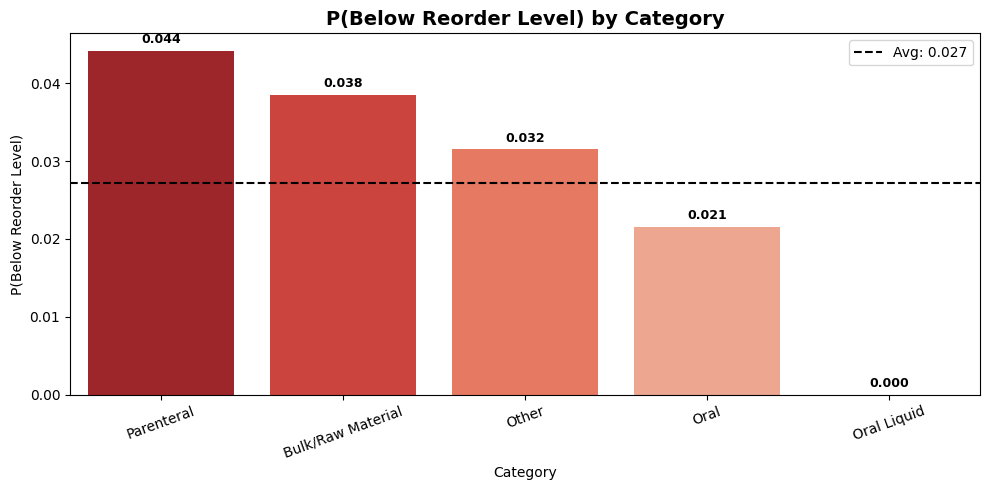

In [15]:
# Visualize
reorder_prob_cat = inventory_data.groupby('Category').agg(
    Total=('Reorder_Flag_Int', 'count'),
    Reorder_Count=('Reorder_Flag_Int', 'sum')
).reset_index()

reorder_prob_cat['P_Reorder'] = (
    reorder_prob_cat['Reorder_Count'] /
    reorder_prob_cat['Total']
).round(4)

reorder_prob_cat = reorder_prob_cat.sort_values('P_Reorder', ascending=False)
print(reorder_prob_cat.to_string())

lb.plt.figure(figsize=(10, 5))
bars = lb.sns.barplot(data=reorder_prob_cat,
                      x='Category',
                      y='P_Reorder',
                      palette='Reds_r')

for i, row in reorder_prob_cat.reset_index().iterrows():
    lb.plt.text(i, row['P_Reorder'] + 0.001,
                f"{row['P_Reorder']:.3f}",
                ha='center', fontsize=9, fontweight='bold')

lb.plt.axhline(y=reorder_prob_cat['P_Reorder'].mean(),
               color='black', linestyle='--',
               label=f"Avg: {reorder_prob_cat['P_Reorder'].mean():.3f}")

lb.plt.title('P(Below Reorder Level) by Category',
             fontsize=14, fontweight='bold')
lb.plt.xlabel('Category')
lb.plt.ylabel('P(Below Reorder Level)')
lb.plt.xticks(rotation=20)
lb.plt.legend()
lb.plt.tight_layout()
lb.plt.show()

# Profit Distribution — Delivered vs Returned Orders

# Category vs Below Reorder Level (Sampling Distribution of Proportion)

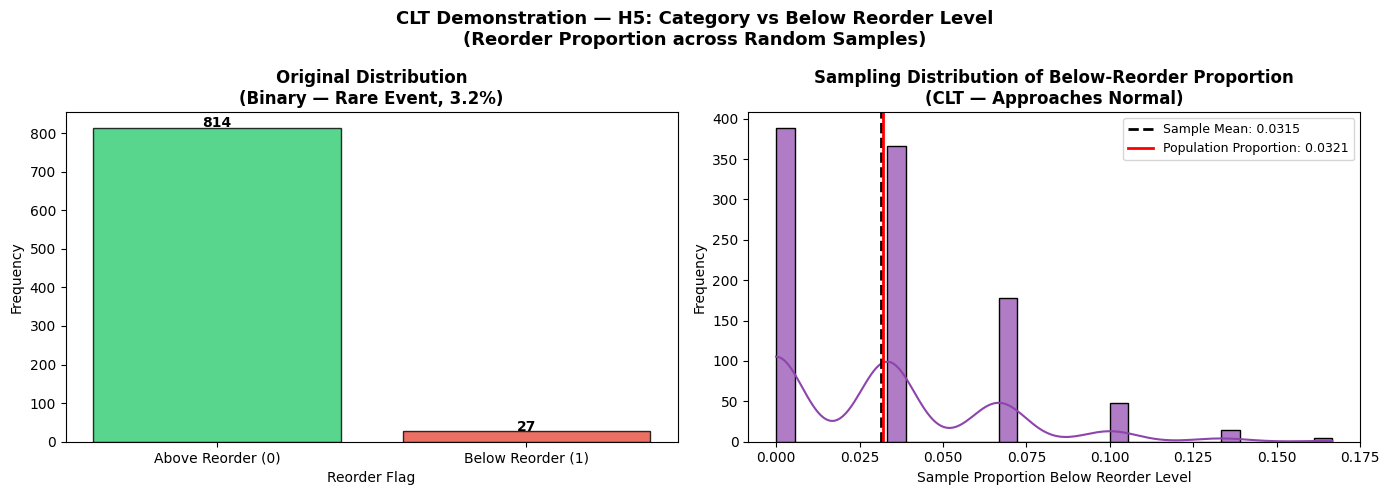

Population Below-Reorder Proportion : 0.0321
Mean of Sample Proportions          : 0.0315
Std of Sample Proportions           : 0.0326
Standard Error (theory)             : 0.0322


In [16]:
# CLT — H5: Sampling Distribution of Reorder_Flag Proportion

inventory_data['Reorder_Flag_Int'] = inventory_data['Reorder_Flag'].astype(int)

col          = 'Reorder_Flag_Int'
sample_size  = 30        # smaller — only 841 total rows in inventory
n_samples    = 1000
sample_props = []

for _ in range(n_samples):
    sample = inventory_data[col].sample(sample_size, replace=True)
    sample_props.append(sample.mean())

pop_proportion = inventory_data[col].mean()

fig, axes = lb.plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
axes[0].bar(['Above Reorder (0)', 'Below Reorder (1)'],
            inventory_data[col].value_counts().sort_index().values,
            color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0].set_title('Original Distribution\n(Binary — Rare Event, 3.2%)', fontweight='bold')
axes[0].set_ylabel('Frequency')
axes[0].set_xlabel('Reorder Flag')
for bar, val in zip(axes[0].patches,
                    inventory_data[col].value_counts().sort_index().values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 str(val), ha='center', fontweight='bold')

# Sampling distribution
lb.sns.histplot(sample_props, kde=True, ax=axes[1],
                color='#8e44ad', bins=30, alpha=0.7)
axes[1].axvline(lb.np.mean(sample_props), color='black', linestyle='--', linewidth=2,
                label=f'Sample Mean: {lb.np.mean(sample_props):.4f}')
axes[1].axvline(pop_proportion, color='red', linestyle='-', linewidth=2,
                label=f'Population Proportion: {pop_proportion:.4f}')
axes[1].set_title('Sampling Distribution of Below-Reorder Proportion\n(CLT — Approaches Normal)', fontweight='bold')
axes[1].set_xlabel('Sample Proportion Below Reorder Level')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)

lb.plt.suptitle('CLT Demonstration — H5: Category vs Below Reorder Level\n(Reorder Proportion across Random Samples)',
                fontsize=13, fontweight='bold')
lb.plt.tight_layout()
lb.plt.show()

print(f'Population Below-Reorder Proportion : {pop_proportion:.4f}')
print(f'Mean of Sample Proportions          : {lb.np.mean(sample_props):.4f}')
print(f'Std of Sample Proportions           : {lb.np.std(sample_props):.4f}')
print(f'Standard Error (theory)             : {lb.np.sqrt(pop_proportion*(1-pop_proportion)/sample_size):.4f}')

# Returned Orders vs Profit

In [17]:
# H0: Profit is equal across returned and delivered orders
# H1: Returned orders have significantly lower profit


In [18]:
demand_data = lb.pd.read_csv("Dataset/demand_sales_cleaned.csv")

profit_returned  = demand_data[demand_data['Order_Status'] == 'Returned']['Profit']
profit_delivered = demand_data[demand_data['Order_Status'] == 'Delivered']['Profit']

print("Profit — Returned Orders:")
print(profit_returned.describe().round(3))

print("\nProfit — Delivered Orders:")
print(profit_delivered.describe().round(3))

t_stat, p_value = lb.stats.ttest_ind(profit_returned, profit_delivered)

print(f"\nT-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")
print(f"\nSignificance Level : 0.05")

if p_value < 0.05:
    print("Result: REJECT H0")
    print("Returned orders have significantly lower profit than delivered orders")
else:
    print("Result: FAIL TO REJECT H0")
    print("Profit is equal across returned and delivered orders")

Profit — Returned Orders:
count    1681.000
mean     -113.716
std       279.451
min     -6602.500
25%       -75.700
50%       -53.350
75%       -45.350
max       -40.230
Name: Profit, dtype: float64

Profit — Delivered Orders:
count    11310.000
mean       139.855
std        359.457
min         -5.120
25%          5.720
50%         41.820
75%        114.587
max       8202.500
Name: Profit, dtype: float64

T-Statistic : -27.7046
P-Value     : 0.0000

Significance Level : 0.05
Result: REJECT H0
Returned orders have significantly lower profit than delivered orders


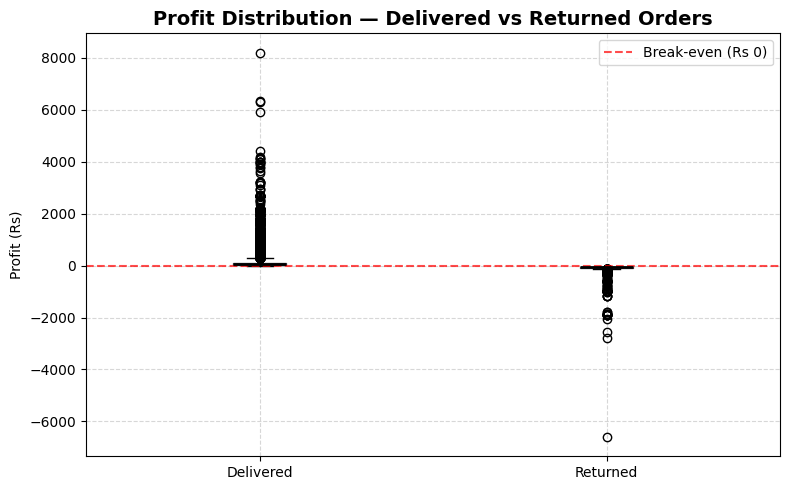

In [19]:
# Visualize
lb.plt.figure(figsize=(8, 5))
lb.plt.boxplot(
    [profit_delivered, profit_returned],
    labels=['Delivered', 'Returned'],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)
lb.plt.axhline(y=0, color='red', linestyle='--',
               alpha=0.7, label='Break-even (Rs 0)')
lb.plt.title('Profit Distribution — Delivered vs Returned Orders',
             fontsize=14, fontweight='bold')
lb.plt.ylabel('Profit (Rs)')
lb.plt.grid(True, linestyle='--', alpha=0.5)
lb.plt.legend()
lb.plt.tight_layout()
lb.plt.show()

# Returned Orders vs Profit (CLT on Means)

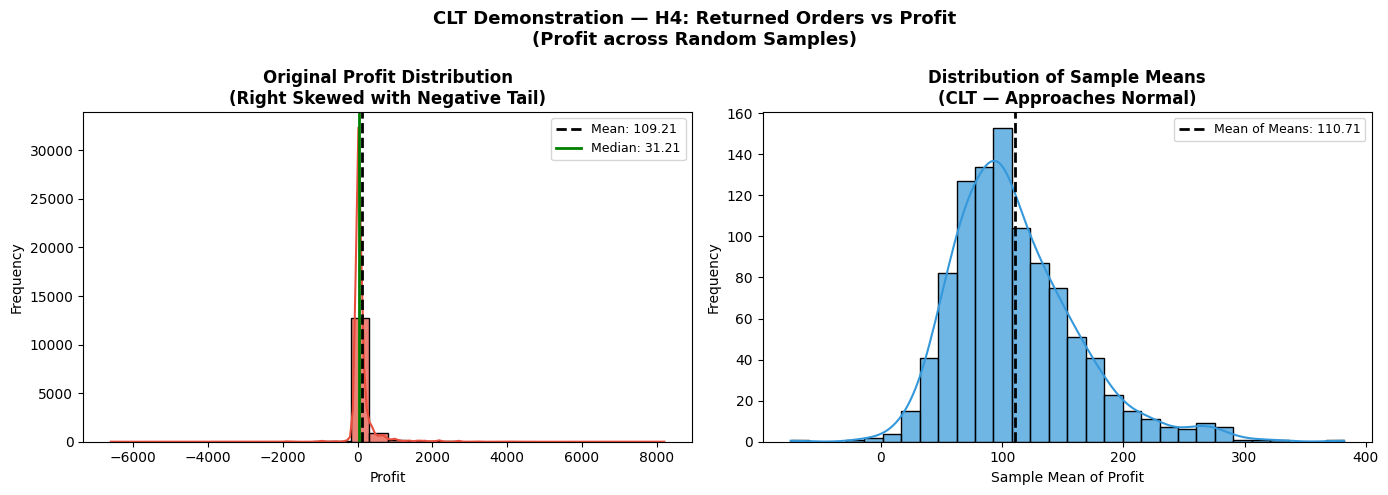

Population Mean Profit : 109.2143
Mean of Sample Means   : 110.7144
Std of Sample Means    : 52.1259
Standard Error (theory): 50.2714


In [20]:
# CLT — H4: Sampling Distribution of Profit

col          = 'Profit'
sample_size  = 50
n_samples    = 1000
sample_means = []

for _ in range(n_samples):
    sample = demand_data[col].sample(sample_size, replace=True)
    sample_means.append(sample.mean())

fig, axes = lb.plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
lb.sns.histplot(demand_data[col], kde=True, ax=axes[0],
                color='#e74c3c', bins=30, alpha=0.7)
axes[0].axvline(demand_data[col].mean(), color='black', linestyle='--', linewidth=2,
                label=f'Mean: {demand_data[col].mean():.2f}')
axes[0].axvline(demand_data[col].median(), color='green', linestyle='-', linewidth=2,
                label=f'Median: {demand_data[col].median():.2f}')
axes[0].set_title('Original Profit Distribution\n(Right Skewed with Negative Tail)', fontweight='bold')
axes[0].set_xlabel('Profit')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# Sampling distribution
lb.sns.histplot(sample_means, kde=True, ax=axes[1],
                color='#3498db', bins=30, alpha=0.7)
axes[1].axvline(lb.np.mean(sample_means), color='black', linestyle='--', linewidth=2,
                label=f'Mean of Means: {lb.np.mean(sample_means):.2f}')
axes[1].set_title('Distribution of Sample Means\n(CLT — Approaches Normal)', fontweight='bold')
axes[1].set_xlabel('Sample Mean of Profit')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)

lb.plt.suptitle('CLT Demonstration — H4: Returned Orders vs Profit\n(Profit across Random Samples)',
                fontsize=13, fontweight='bold')
lb.plt.tight_layout()
lb.plt.show()

print(f'Population Mean Profit : {demand_data[col].mean():.4f}')
print(f'Mean of Sample Means   : {lb.np.mean(sample_means):.4f}')
print(f'Std of Sample Means    : {lb.np.std(sample_means):.4f}')
print(f'Standard Error (theory): {demand_data[col].std() / lb.np.sqrt(sample_size):.4f}')